In [1]:
from glob import glob 
import matplotlib.pyplot as plt 
import numpy as np 
import pandas as pd
from importlib import reload
import matplotlib.gridspec as gridspec
from matplotlib.cm import get_cmap,  ScalarMappable
import meanfield.hebbian_meanfield as mf
import seaborn as sns
from tqdm import tqdm
import os
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import colormaps as cmaps
outdir = '/Users/albertwakhloo/Documents/GitHub/dynamic-memories/results'
figdir = '/Users/albertwakhloo/Documents/GitHub/dynamic-memories/figs'

#### TODO: would be better to run the full simulation of the A matrix...

In [2]:
def plot_fancy(X,ax, halt_time, T, dt, color, fn, Nplot=6,  draw_inputs=True): 
    T = np.linspace(0,T,int(T/dt), endpoint=False)
    resample = np.linspace(0.4, 0.8, Nplot)
    alphas = np.linspace(0.2,1.0,Nplot)
    for i in range(Nplot):
        ax.plot(T-T[-1] * halt_time, X[:, i], color=color,alpha=alphas[i])
    if draw_inputs:
        ymin, ymax = ax.get_ylim()
        ax.vlines(0, ymin, ymax, color='grey', ls=':', lw=2, label='stim. off')
        ax.set_ylim(ymin, ymax)
    ax.set_xlabel(r't', fontsize=fn) 
    ax.set_ylabel(r'x(t)',fontsize=fn)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    return ax 

In [3]:
def load_outlier_dat(path, eps = 0.075): 
    files = glob(path + '/*.npy')
    dfs = [] 
    for f in files: 
        arr = np.load(f, allow_pickle=True).item() 
        if 'freqs' not in arr.keys():
            continue 
        I, g, k, p, f, life, freqs  = arr['I'], arr['g'], arr['k'], arr['p'], arr['f'], arr['life'], arr['freqs'] 
        eig = arr['eigs']
        if type(eig)==list: eig = np.stack(eig) 
        # get the outlier for each batch and timepoint
        n_times, n_batch, N = eig.shape
        # assert n_times ==1 
        if n_times !=1: 
            print('check')
            continue 
        eig = eig.squeeze() 
        ind = np.abs(eig).argmax(axis=-1)
        eig = eig[np.arange(n_batch), ind] # outliers 
        print('eshape = ', eig.shape)
        # threshold outliers
        eig[np.abs(eig) <= g + eps] = np.nan
        # data formatting
        dct = {'I' : np.ones(n_batch) * I,
               'f' :  np.ones(n_batch) * f,
               'k' :  np.ones(n_batch) * k,
               'p' :  np.ones(n_batch) * p, 
               'g' : np.ones(n_batch) * g,
               'life' : life, 
               'freqs' : freqs,
               'eig_re' : eig.real,
              'eig_im' : eig.imag}
        df = pd.DataFrame(dct, index=np.arange(n_batch))
        X = arr['Xh']
        dfs.append(df)
    return pd.concat(dfs,ignore_index=True).dropna(), X
        

def load_examples(path): 
    '''load up an example for the first subpanels''' 
    files = glob(path + '/*_k_3.0.npy')
    eigs, Xs = [] , [] 
    evec_J, evec_A, eig_J = [], [], []
    for f in sorted(files)[::-1]: 
        # get the traces and eigenvalues 
        arr = np.load(f,allow_pickle=True).item() 
        print(list(arr.keys()))
        eig = arr['eigs'] 
        if type(eig) == list : eig=np.stack(eig)
        print(arr.keys())
        Xs.append(arr['Xh'])
        eigs.append(eig)
        # get the eigenvectors for the overlap statistics 
        J,A_all=arr['J'], arr['A'] 
        A_times=arr['A_times'] 
        A = A_all[:, np.argmin(np.abs(T*halt_time - A_times))]
        eJ, vJ = np.linalg.eig(J) 
        _, vA = np.linalg.eigh(A) 
        evec_J.append(vJ), evec_A.append(vA), eig_J.append(eJ)
    return eigs, Xs, evec_J, evec_A, eig_J 


def get_olaps(evec_J, evec_A): 
    # top two eigenvectors of A 
    u,v = evec_A[:,-1], evec_A[:,-2] 
    overlaps = [] 
    for i in range(len(evec_J)): 
        uprime, vprime = evec_J[:,i].real, evec_J[:,i].imag
        A = np.stack([uprime, vprime], axis=1) 
        B = np.stack([u,v],axis=1) 
        olap = np.linalg.norm(A.T @ B, ord='fro') 
        # olap = np.abs(np.dot(uprime+1j*vprime, u-1j*v))
        overlaps.append(olap)
    return np.array(overlaps) 

In [4]:
def get_outlier_dynamics(eig, g, b, thresh =0.05): 
    '''assume a t x n_batch x n_eig array''' 
    # get the outlier for each batch and timepoint
    n_times, n_batch, N = eig.shape
    eig = eig.reshape(n_times*n_batch, N)
    ind = np.abs(eig).argmax(axis=-1)
    eig = eig[np.arange(n_batch * n_times), ind] # maxed 
    eig[np.abs(eig) <= g + thresh] = 0.     
    # reshape and average 
    eig = eig.reshape(n_times, n_batch)
    # re, im = eig.real.mean(1), eig.imag.mean(1) 
    re, im = eig.real[:, b], eig.imag[:, b]
    re_std, im_std = eig.real.std(1), eig.imag.std(1)
    return re, im, re_std, im_std
    

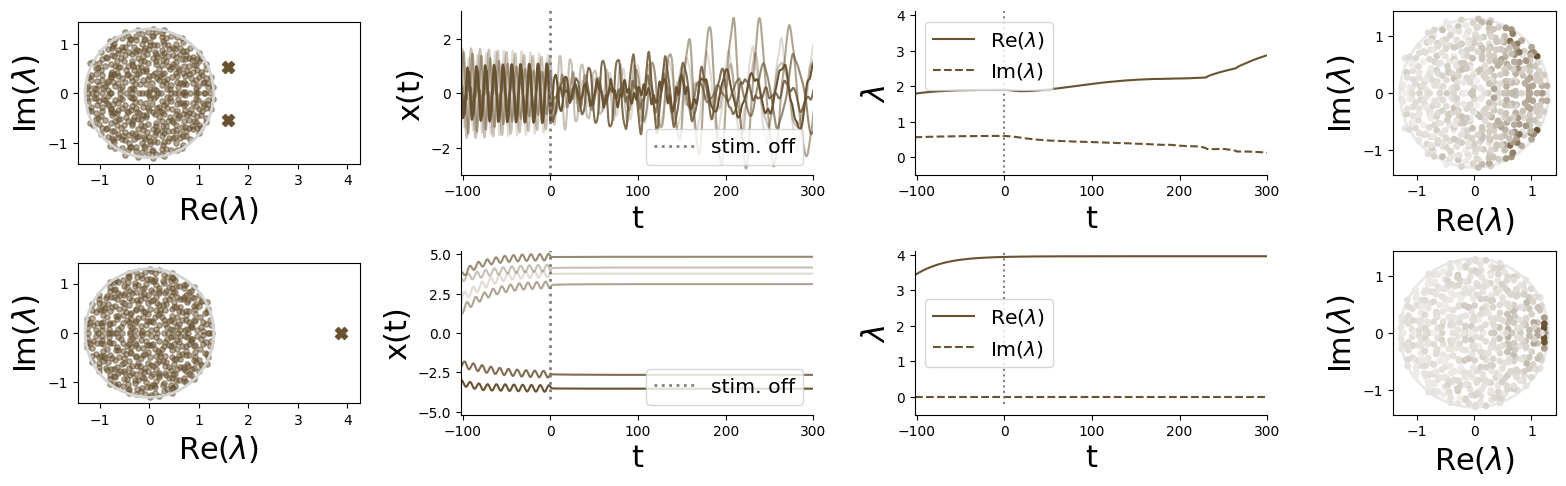

In [5]:
# epath = outdir + '/eig_at_halt/A-matrices-dt-0.1_grid_examples/' 
epath = outdir + '/eig_at_halt/A-matrices-dt-0.1_grid_examples_N_500/' 
w = 16
hw_ratio = 5 / 16 
fn = 22
b=0 # 3 #4 
s=15
fig, axs = plt.subplots(2,4,figsize=(w, w*hw_ratio),gridspec_kw={'width_ratios': [.8, 1,1, 0.6]})


# sr = np.load(glob(epath +'/eigvals*.npy')[0],allow_pickle=True).item()
# halt_time, T, dt =sr['halt_time'], sr['T'], sr['dt'] 
# g = sr['g'] 
# eigs, Xs, evec_J, evec_A, eig_J  = load_examples(epath)
# for i in range(2): 
#     eig, X = eigs[i], Xs[i] 
#     X = X[b]
#     # slice halt moment and batch
#     eig_thalt = eig[len(eig)//2, b]
#     re, im, *_ = get_outlier_dynamics(eig, g, b)
#     olaps = get_olaps(evec_J[i][b], evec_A[i][b]) 
#     eJ = eig_J[i][b]
#     smry_res = {'eig' : eig, 
#                 'X' : X ,
#                 'eig_thalt' : eig_thalt, 
#                 're' : re, 
#                 'im' : im, 
#                 'olaps' :olaps,
#                 'eJ' : eJ,
#                 'halt_time' : halt_time,
#             'T' : T,
#             'dt' : dt,
#             'g' : g}
#     np.save(epath + f'/smry_stats_{i}.npy', np.array(smry_res))


cs = ['#685231', '#685231']
    

for i in range(2): 
    arr = np.load(epath + f'/smry_stats_{i}.npy', allow_pickle=True).item() 
    eig, X, eig_thalt, re, im, olaps, eJ, halt_time, T, dt, g = arr.values() 
    
    
    bulk = eig_thalt[np.abs(eig_thalt) <= g+0.1]
    out = eig_thalt[np.abs(eig_thalt) >= g+0.1]
    axs[i,0].scatter(bulk.real,bulk.imag,c=cs[i],s=s,alpha=.5)
    axs[i,0].scatter(out.real,out.imag,c=cs[i],s=s*5,marker='X',alpha=1.0)
    
    axs[i,0].set_xlabel(r'$\mathrm{Re}(\lambda)$',fontsize=fn) 
    axs[i,0].set_ylabel(r'$\mathrm{Im}(\lambda)$', fontsize=fn)
    
    
    plot_fancy(X, axs[i,1],  halt_time, T, dt, fn=fn, color=cs[i])
    axs[i,1].legend(fontsize=fn*2/3,loc='lower right')

    
    
    time_vec = np.linspace(0,T,len(re))
    axs[i,2].plot(time_vec - T*halt_time, re, c=cs[i], label=r'$\mathrm{Re}(\lambda)$')
    axs[i,2].plot(time_vec - T*halt_time, im, c=cs[i], ls='--',label=r'$\mathrm{Im}(\lambda)$')
    ylim = axs[i,2].get_ylim()
    axs[i,2].vlines(0, *ylim, color='grey', ls=':') 
    axs[i,2].set_ylim(ylim) 
    axs[i,2].set_xlabel('t',fontsize=fn) 
    axs[i,2].set_ylabel(r'$\lambda$', fontsize=fn) 

    xlim = (-102, 300)
    axs[i,1].set_xlim(xlim) 
    axs[i,2].set_xlim(xlim)
    axs[i,2].spines['top'].set_visible(False)
    axs[i,2].spines['right'].set_visible(False)

    axs[i,0].set_xlim(-g-0.15, 4+0.25)
    axs[i,2].set_ylim([-0.5,4.1])
    loc = 'center left' if i ==1 else 'upper left' 
    axs[i,2].legend(fontsize=fn*2/3, loc =loc)


    circ = plt.Circle((0, 0), g, color='lightgrey',alpha=1., fill=False, lw=2.)
    axs[i,0].add_patch(circ)
    
    circ2 = plt.Circle((0, 0), g, color='lightgrey',alpha=0.5, fill=False, lw=2.)
    axs[i,3].add_patch(circ2) 
    cm = sns.light_palette(cs[0], as_cmap=True)
    im=axs[i,3].scatter(eJ.real, eJ.imag, c=olaps, cmap=cm, s=s, alpha=1.) 
    # cbar=plt.colorbar(im, ax=axs[i,3])
    axs[i,3].set_xlabel(r'$\mathrm{Re}(\lambda)$',fontsize=fn) 
    axs[i,3].set_ylabel(r'$\mathrm{Im}(\lambda)$', fontsize=fn)

    axs[i,0].set_aspect(1) 
    axs[i,3].set_aspect(1)
    
    
axs[0,1].set_ylim([-3,3])
axs[1,1].set_ylim([-5.2,5.2])
plt.tight_layout()
fig.savefig(figdir+'/fig_3_examples.png', dpi=300, bbox_inches='tight', transparent=True)

In [8]:
# reload(mf)
# path = outdir + '/eig_at_halt/A-matrices-dt-0.1_grid_dense'
# df, X = load_outlier_dat(path) 
# np.save(epath + '/smry.npy', {'df' : df, 'X' : X})

arr = np.load(epath +  '/smry.npy', allow_pickle=True).item() 
df, X = arr.values() 

mdf = df.groupby(['I', 'f', 'k', 'p']).mean().reset_index()

In [9]:
def nadaraya_watson_smoothing(x, y, z, grid_size, distance_threshold,replace, bandwidth):
    """
    Perform Nadaraya-Watson kernel smoothing and mask points beyond a distance threshold.

    Parameters:
        x (array-like): X coordinates of the recorded data.
        y (array-like): Y coordinates of the recorded data.
        z (array-like): Measurement values at the recorded (x, y) points.
        grid_size (tuple): Size of the output grid (nx, ny).
        distance_threshold (float): Maximum allowed distance from recorded points.
        bandwidth (float): Bandwidth of the Gaussian kernel.

    Returns:
        grid_z (ndarray): Smoothed grid with NaNs for points beyond the distance threshold.
    """
    # Create a grid to interpolate onto
    nx, ny = grid_size
    grid_x, grid_y = np.meshgrid(np.linspace(min(x), max(x), nx), np.linspace(min(y), max(y), ny))
    grid_points = np.column_stack((grid_x.ravel(), grid_y.ravel()))  # Flatten grid for vectorized operations

    # Stack recorded points
    recorded_points = np.column_stack((x, y))

    # Compute pairwise distances between grid points and recorded points
    # Using broadcasting to avoid explicit loops
    diff = grid_points[:, np.newaxis, :] - recorded_points[np.newaxis, :, :]  # Shape: (n_grid, n_recorded, 2)
    distances = np.linalg.norm(diff, axis=2)  # Shape: (n_grid, n_recorded)

    # Compute Gaussian kernel weights
    weights = np.exp(-(distances ** 2) / (2 * bandwidth ** 2))  # Shape: (n_grid, n_recorded)
    weights /= np.sum(weights, axis=1, keepdims=True)  # Normalize weights

    # Perform Nadaraya-Watson smoothing
    grid_z = np.sum(weights * z[np.newaxis, :], axis=1)  # Shape: (n_grid,)

    # Reshape the result to match the grid
    grid_z = grid_z.reshape(grid_x.shape)

    # Mask points beyond the distance threshold
    min_distances = np.min(distances, axis=1).reshape(grid_x.shape)  # Shape: (nx, ny)
    grid_z[min_distances > distance_threshold] = np.nan
    

    return grid_z, grid_x, grid_y


def make_sym_contour(ax,x,y,z,gsize,eps,replace,bw,cmap=None,circ_c='grey',label=None,n_levels=7): 
    gzp, gxp, gyp = nadaraya_watson_smoothing(x, y, z, 
                                  (gsize, gsize),
                                  eps,
                                    replace, bw)
    gzm, gxm, gym = nadaraya_watson_smoothing(x,-y,z,
                                      (gsize, gsize),
                                      eps,
                                        replace, bw)
    levels=np.linspace(z.min(),z.max(),n_levels)
    print(levels)
    im=ax.contourf(gxp,gyp,gzp,cmap=cmap,levels=levels)
    ax.contourf(gxm,gym,gzm,cmap=cmap,levels=levels)

    # colorbar
    cbf = plt.colorbar(im, ax=ax)
    cbf.set_label(label=label, fontsize=fn, rotation=90)
    
    # add circle to illustrate the bulk 
    circ = plt.Circle((0, 0), g, color=circ_c,alpha=0.3)
    ax.add_patch(circ)
    ax.set_xlabel(r'$\mathrm{Re}(\lambda)$',fontsize=fn) 
    ax.set_ylabel(r'$\mathrm{Im}(\lambda)$',fontsize=fn) 
    ax.set_xlim([0.,4.])
    
    

[  0.  50. 100. 150. 200. 250. 300. 350. 400. 450. 500. 550. 600. 650.
 700.]
[0.         0.00761905 0.0152381  0.02285714 0.03047619 0.03809524
 0.04571429 0.05333333 0.06095238 0.06857143 0.07619048 0.08380952
 0.09142857 0.09904762 0.10666667]


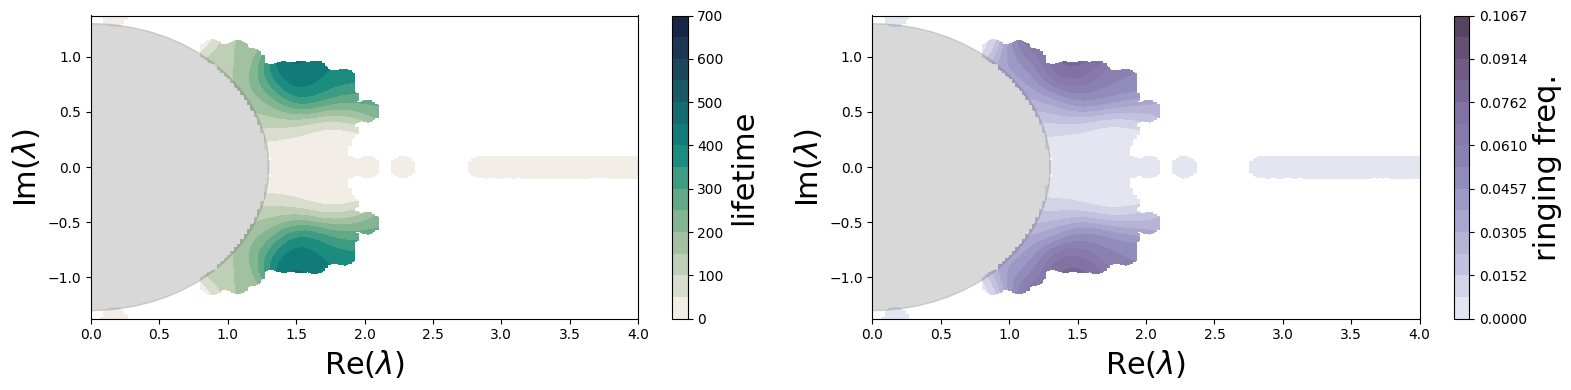

In [10]:
gsize = 250
fn=22
eps=0.1
bw=0.1
replace=np.nan
n_levels=15
hw_r = 4 / 16 
# hw_r = 5/16
w = 16 
fig, ax = plt.subplots(1,2,figsize=(w,w*hw_r))

make_sym_contour(ax[0], df.eig_re.values, 
                 df.eig_im.values, df.life.values, 
                 gsize,eps,replace,
                 bw,cmap=cmaps.tempo,label='lifetime',
                n_levels=n_levels)

make_sym_contour(ax[1], df.eig_re.values, 
                 df.eig_im.values, df.freqs.values, 
                 gsize,eps,
                 replace,bw,
                 cmap=cmaps.pr_mist,label='ringing freq.', #cmaps.amp #cmaps.pr_mist
                n_levels=n_levels)
# plt.subplots_adjust(wspace=0.35)
plt.tight_layout()
plt.show() 

In [12]:
fig.savefig(figdir+'/fig_3_heatmap.png', dpi=300, transparent=True,
           bbox_inches='tight')